In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
import pandas as pd
ah = pd.read_csv("nba_savant 2015-2016 a-h.csv")
im = pd.read_csv("nba_savant 2015-2016 i-m.csv")
nz = pd.read_csv("nba_savant 2015-2016 n-z.csv")
df = pd.concat([ah,im,nz], ignore_index = True)

print(len(ah)+len(im)+len(nz))
print(len(df))

print(df.head())




145986
145986
              name        team_name   game_date  season  espn_player_id  \
0     Clint Capela  Houston Rockets  2016-01-24    2015       3102529.0   
1     Clint Capela  Houston Rockets  2015-10-28    2015       3102529.0   
2  Tim Hardaway Jr    Atlanta Hawks  2016-01-09    2015       2528210.0   
3   Andre Drummond  Detroit Pistons  2015-10-28    2015          6585.0   
4   Kenneth Faried   Denver Nuggets  2016-02-08    2015          6433.0   

      team_id  espn_game_id  period  minutes_remaining  seconds_remaining  \
0  1610612745     400828552       4                  1                 26   
1  1610612745     400827897       2                  4                 50   
2  1610612737     400828438       1                  2                  0   
3  1610612765     400827894       3                  2                 28   
4  1610612743     400828665       2                  4                  1   

   ...       shot_type shot_distance          opponent   x   y  dribbles

In [3]:
df.drop(["defender_name","name","team_name","game_date","season","espn_player_id","team_id","espn_game_id","opponent"], axis=1, inplace = True)


In [4]:
df["seconds"] = 60*df["minutes_remaining"]+df["seconds_remaining"]

In [5]:
df.drop(["minutes_remaining","seconds_remaining"],axis = 1, inplace = True)

In [6]:
df.head(500)

,period,shot_made_flag,action_type,shot_type,shot_distance,x,y,dribbles,touch_time,defender_distance,shot_clock,seconds
0,4,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0,0.0,0.0,0.0,86
1,2,1,Alley Oop Dunk Shot,2PT Field Goal,3,-25,31,0,0.0,2.7,12.9,290
2,1,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0,0.0,4.9,20.4,120
3,3,1,Alley Oop Dunk Shot,2PT Field Goal,3,18,26,0,0.0,3.3,0.0,148
4,2,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0,0.0,0.0,0.0,241
...,...,...,...,...,...,...,...,...,...,...,...,...
495,3,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,1,1.7,5.0,24.0,645
496,4,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0,0.0,0.0,0.0,168
497,4,1,Alley Oop Dunk Shot,2PT Field Goal,0,0,1,0,0.0,2.4,7.1,358
498,3,1,Alley Oop Dunk Shot,2PT Field Goal,0,9,-3,0,0.0,0.0,0.0,394


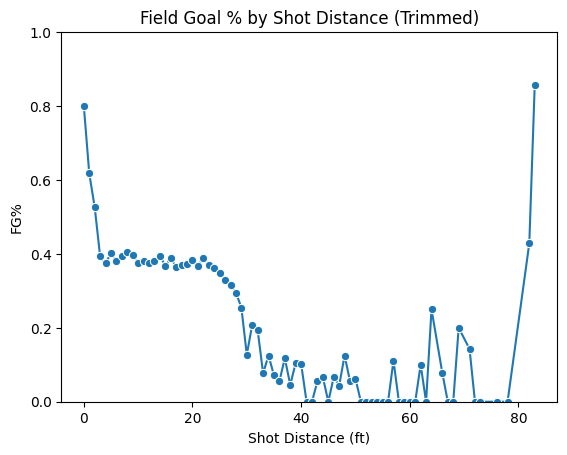

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Group by distance: FG% and number of attempts
fg_counts = (
    df.groupby("shot_distance")
      .agg(
          fg_pct=("shot_made_flag", "mean"),
          attempts=("shot_made_flag", "count")
      )
      .reset_index()
)

# Filter out distances with too few attempts (e.g., < 5)
fg_clean = fg_counts[fg_counts["attempts"] >= 5]

# Plot FG% vs Distance
sns.lineplot(
    data=fg_clean,
    x="shot_distance",
    y="fg_pct",
    marker="o"
)

plt.title("Field Goal % by Shot Distance (Trimmed)")
plt.xlabel("Shot Distance (ft)")
plt.ylabel("FG%")
plt.ylim(0, 1)
plt.show()


/var/folders/n6/z7jbsp8j70ndw874hkqlzqfh0000gn/T/ipykernel_31492/4146396052.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trimmed['points'] = np.where(df_trimmed['shot_distance'] > 23.75, 3, 2)  # 3-point line
/var/folders/n6/z7jbsp8j70ndw874hkqlzqfh0000gn/T/ipykernel_31492/4146396052.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_trimmed['points'] *= df_trimmed['shot_made_flag']  # Multiply by make/miss


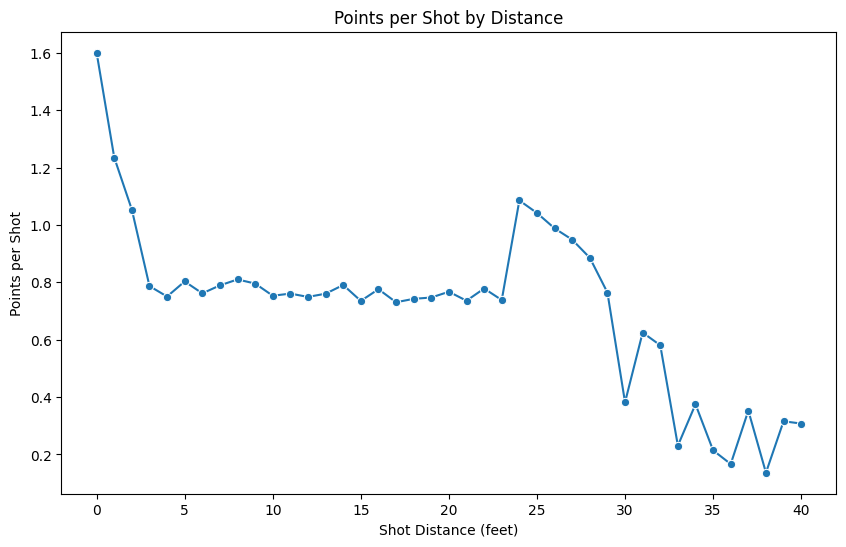

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Example DataFrame
# df = pd.read_csv("your_data.csv")

# 1. Trim outliers (e.g., shots over 40 feet)
df_trimmed = df[df['shot_distance'] <= 40]

# 2. Assign points based on distance
df_trimmed['points'] = np.where(df_trimmed['shot_distance'] > 23.75, 3, 2)  # 3-point line
df_trimmed['points'] *= df_trimmed['shot_made_flag']  # Multiply by make/miss

# 3. Compute average points per shot for each distance
pps = df_trimmed.groupby('shot_distance')['points'].mean().reset_index()

# 4. Plot
plt.figure(figsize=(10,6))
sns.lineplot(x='shot_distance', y='points', data=pps, marker='o')
plt.ylabel('Points per Shot')
plt.xlabel('Shot Distance (feet)')
plt.title('Points per Shot by Distance')
plt.show()


In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Prepare features for modeling
numerical_features = ['shot_distance', 'defender_distance', 'shot_clock', 
                     'touch_time', 'dribbles', 'x', 'y', 'seconds', 'period']

# Filter to only include columns that exist in your dataframe
available_features = [col for col in numerical_features if col in df.columns]

# Create dummy variables for categorical features
df_encoded = df.copy()
if 'action_type' in df.columns:
    action_dummies = pd.get_dummies(df['action_type'], prefix='action_type', drop_first=True)
    df_encoded = pd.concat([df_encoded, action_dummies], axis=1)
    available_features.extend(action_dummies.columns.tolist())

if 'shot_type' in df.columns:
    shot_type_dummies = pd.get_dummies(df['shot_type'], prefix='shot_type', drop_first=True)
    df_encoded = pd.concat([df_encoded, shot_type_dummies], axis=1)
    available_features.extend(shot_type_dummies.columns.tolist())

# Prepare X and y
X = df_encoded[available_features]
y = df_encoded['shot_made_flag']

# Handle missing values
X = X.fillna(X.median())

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# Results
print("LOGISTIC REGRESSION RESULTS")
print("=" * 40)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': available_features,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print("\nFeature Coefficients:")
print(feature_importance)

LOGISTIC REGRESSION RESULTS
Accuracy: 0.655
AUC Score: 0.690

Classification Report:
              precision    recall  f1-score   support

           0       0.65      0.83      0.73     16216
           1       0.67      0.44      0.53     12982

    accuracy                           0.65     29198
   macro avg       0.66      0.63      0.63     29198
weighted avg       0.66      0.65      0.64     29198


Feature Coefficients:
                                       feature  coefficient
32                       action_type_Jump Shot    -1.476131
33                      action_type_Layup Shot    -0.543186
21              action_type_Driving Layup Shot    -0.411082
30                       action_type_Hook Shot    -0.379832
28              action_type_Floating Jump shot    -0.373404
..                                         ...          ...
34                         action_type_No Shot    -0.006973
11  action_type_Cutting Finger Roll Layup Shot     0.004571
37               action_t

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

# 1. Load data
# df = pd.read_csv("your_data.csv")
y = df['shot_made_flag']

# 2. Drop intuitively low importance features
features_to_drop = ['seconds_remaining', 'period', 'shot_number', 'game_id', 'player_id']  # adjust as needed
X = df.drop(columns=['shot_made_flag'] + features_to_drop, errors='ignore')

# Convert categorical features to numeric
X = pd.get_dummies(X, drop_first=True)

# 3. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Train XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)

# 5. Make predictions
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# 6. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))


/Users/brandonnam/Documents/sports analytics thing/.venv/lib/python3.10/site-packages/xgboost/training.py:183: UserWarning: [22:00:51] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.6607301869991096
Confusion Matrix:
 [[13560  2656]
 [ 7250  5732]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.84      0.73     16216
           1       0.68      0.44      0.54     12982

    accuracy                           0.66     29198
   macro avg       0.67      0.64      0.63     29198
weighted avg       0.67      0.66      0.65     29198

ROC AUC: 0.7019191932444582


Accuracy: 0.6621686416877869
Confusion Matrix:
 [[13494  2722]
 [ 7142  5840]]

Classification Report:
               precision    recall  f1-score   support

           0       0.65      0.83      0.73     16216
           1       0.68      0.45      0.54     12982

    accuracy                           0.66     29198
   macro avg       0.67      0.64      0.64     29198
weighted avg       0.67      0.66      0.65     29198

ROC AUC: 0.7035465247429613


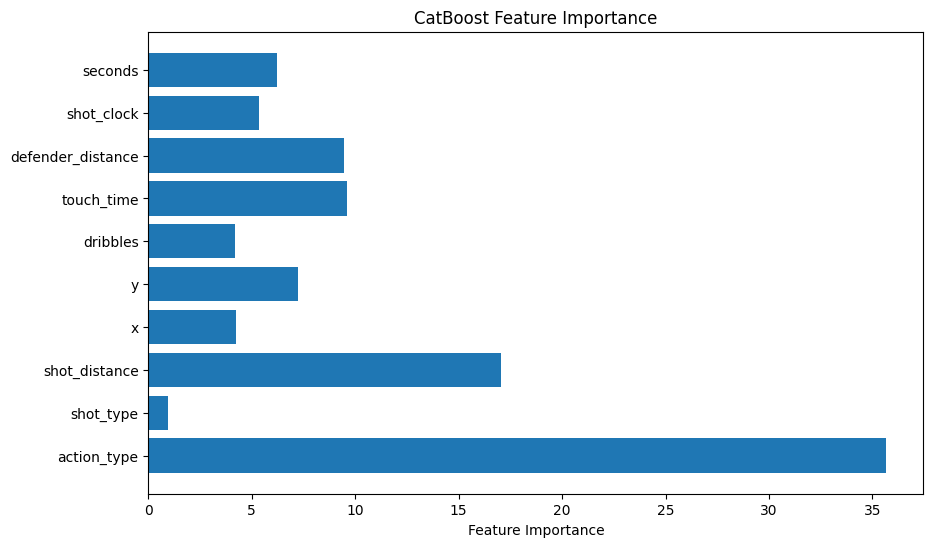

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# 1. Load your data
# df = pd.read_csv("your_data.csv")
y = df['shot_made_flag']

# 2. Drop intuitively low-importance features
features_to_drop = ['seconds_remaining', 'period', 'shot_number', 'game_id', 'player_id']
X = df.drop(columns=['shot_made_flag'] + features_to_drop, errors='ignore')

# Identify categorical features
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# 3. Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4. Create Pool objects for CatBoost
train_pool = Pool(X_train, y_train, cat_features=categorical_features)
test_pool = Pool(X_test, y_test, cat_features=categorical_features)

# 5. Train CatBoost classifier
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=0,              # suppress iteration output
    early_stopping_rounds=50
)
cat_model.fit(train_pool, eval_set=test_pool)

# 6. Make predictions
y_pred = cat_model.predict(X_test)
y_prob = cat_model.predict_proba(X_test)[:, 1]

# 7. Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

# 8. Feature importance plot
importances = cat_model.get_feature_importance(train_pool)
feat_names = X.columns
plt.figure(figsize=(10,6))
plt.barh(feat_names, importances)
plt.xlabel("Feature Importance")
plt.title("CatBoost Feature Importance")
plt.show()
